In [31]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score,roc_curve)


In [32]:
# Load the dataset

df = pd.read_csv("../dataset/diabetes_prediction_dataset_2000.csv")
df.head(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,13.0,0,0,No Info,20.82,5.8,126,0
1,Female,3.0,0,0,No Info,21.00,5.0,145,0
2,Male,63.0,0,0,former,25.32,3.5,200,0
3,Female,2.0,0,0,never,17.43,6.1,126,0
4,Female,33.0,0,0,not current,40.08,6.2,200,1


In [33]:
# Basic dataset checking

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (2000, 9)

Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 4


In [34]:
# Removing duplicates

df = df.drop_duplicates()
print("Shape After Removing duplicates:", df.shape)

Shape After Removing duplicates: (1996, 9)


In [35]:
# Checking diabetes classes

print("Diabetes counts:")
print(df["diabetes"].value_counts())

print("\nPercentage of each class:")
print((df["diabetes"].value_counts(normalize=True) * 100).round(2))

Diabetes counts:
diabetes
0    1831
1     165
Name: count, dtype: int64

Percentage of each class:
diabetes
0    91.73
1     8.27
Name: proportion, dtype: float64


In [36]:
# Separating features and target

X = df.drop("diabetes", axis=1)
y = df["diabetes"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1996, 8)
Target shape: (1996,)


In [37]:
# Identifying categorical and numerical colums

categorical_cols = ["gender", "smoking_history"]

numerical_cols = [
    "age",
    "hypertension",
    "heart_disease",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['gender', 'smoking_history']
Numerical columns: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']


In [38]:
# Preprocessing

prep = ColumnTransformer(transformers=[
        ("num",StandardScaler(),numerical_cols),
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_cols)])

In [39]:
# Splitting the dataset

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (1596, 8)
Testing data: (400, 8)


In [40]:
# Building the KNN model

knn_model = Pipeline(
    steps=[("preprocessing", prep),("knn",KNeighborsClassifier(n_neighbors=5,weights="uniform",metric="minkowski"))])

In [41]:
# Training the KNN model

knn_model.fit(x_train, y_train)

print("KNN model trained successfully.")

KNN model trained successfully.


In [42]:
# Making predictions

knn_pred = knn_model.predict(x_test)
knn_prob = knn_model.predict_proba(x_test)[:, 1]

print("First 10 KNN predictions:")
print(knn_pred[:10])

First 10 KNN predictions:
[0 0 0 0 0 0 0 0 0 0]


In [43]:
# Calculating KNN evaluation metrics

knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test,knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test,knn_pred,average="weighted")
knn_auc = roc_auc_score(y_test, knn_prob)

print("KNN Classification Results")
print("---------------------------")
print("Accuracy    :", knn_accuracy)
print("Precision   :", knn_precision)
print("Recall      :", knn_recall)
print("Weighted F1 :", knn_f1)
print("ROC-AUC     :", knn_auc)

KNN Classification Results
---------------------------
Accuracy    : 0.955
Precision   : 0.8571428571428571
Recall      : 0.5454545454545454
Weighted F1 : 0.9503619302949062
ROC-AUC     : 0.8927834200313766


In [44]:
# Classification report for KNN

print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       367
           1       0.86      0.55      0.67        33

    accuracy                           0.95       400
   macro avg       0.91      0.77      0.82       400
weighted avg       0.95      0.95      0.95       400



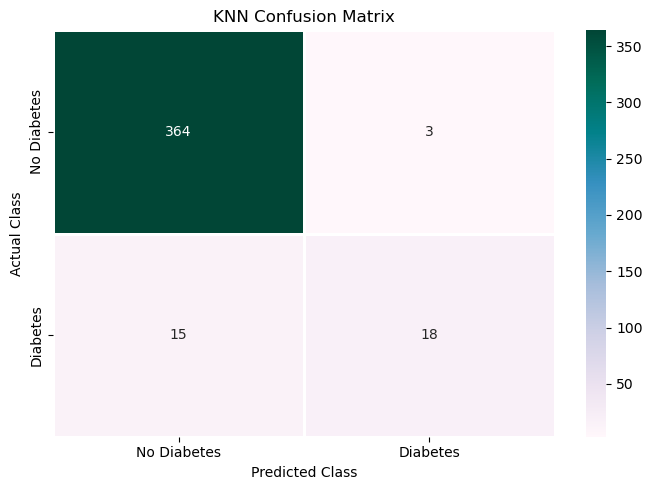

In [45]:
# KNN confusion matrix

cm_knn = confusion_matrix(y_test, knn_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="PuBuGn",
    linewidths=1,
    linecolor="white",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

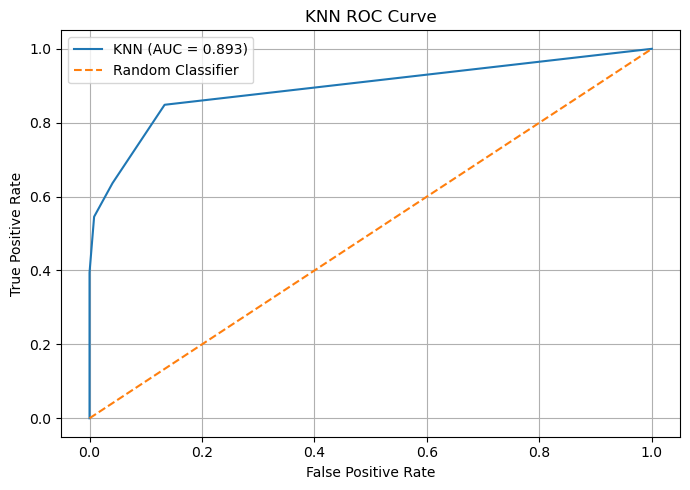

In [46]:
# ROC Curve for KNN

fpr, tpr, thresholds = roc_curve(y_test, knn_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr,tpr,label=f"KNN (AUC = {knn_auc:.3f})")

plt.plot([0, 1],[0, 1], linestyle="--",label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN ROC Curve")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Dataset shape: (2000, 9)

Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 4
Shape After Removing duplicates: (1996, 9)
Diabetes counts:
diabetes
0    1831
1     165
Name: count, dtype: int64

Percentage of each class:
diabetes
0    91.73
1     8.27
Name: proportion, dtype: float64


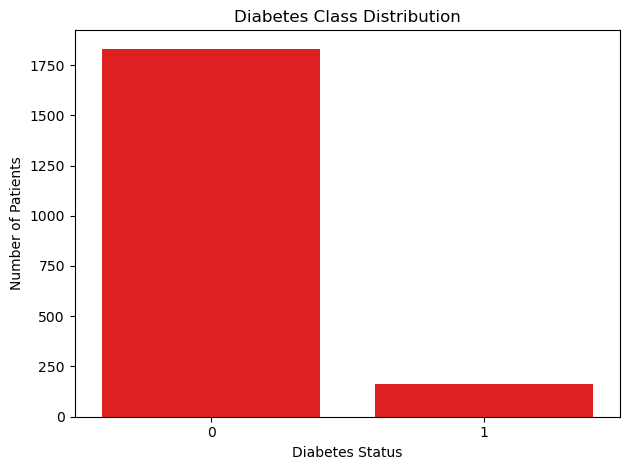

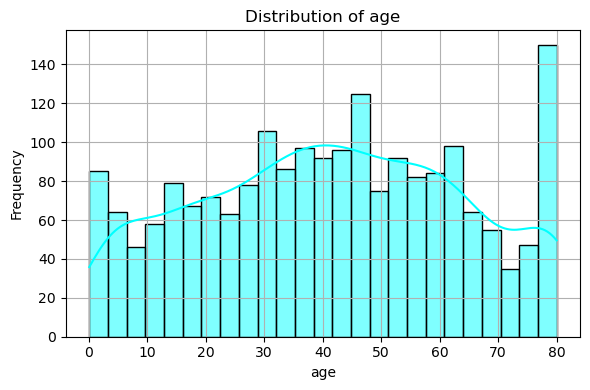

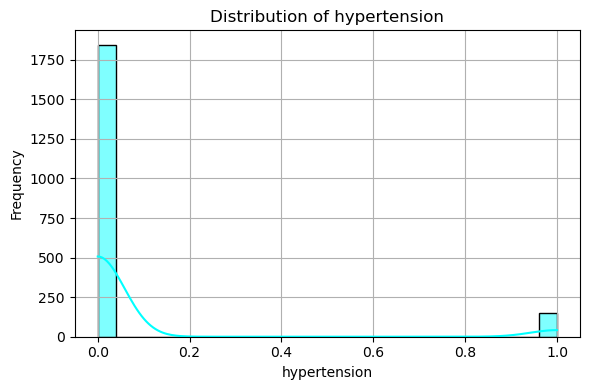

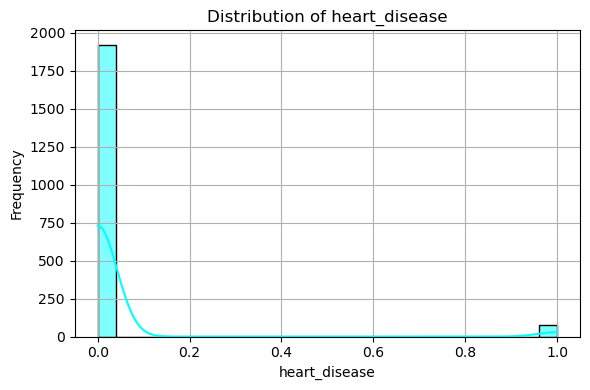

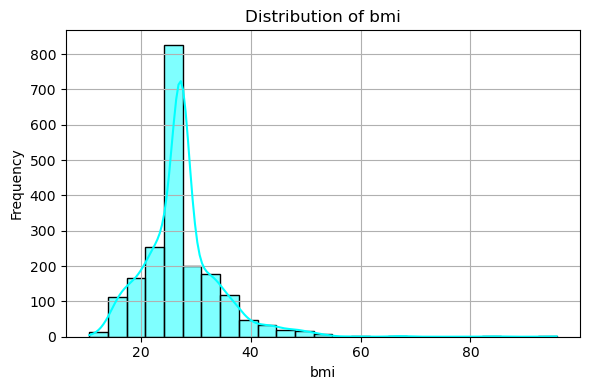

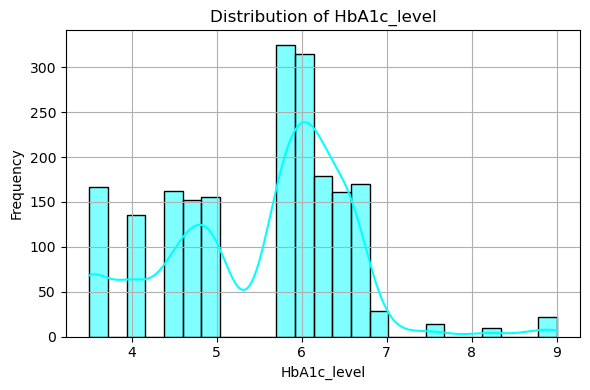

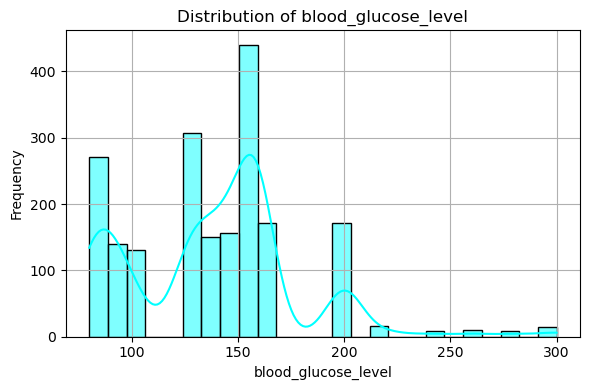

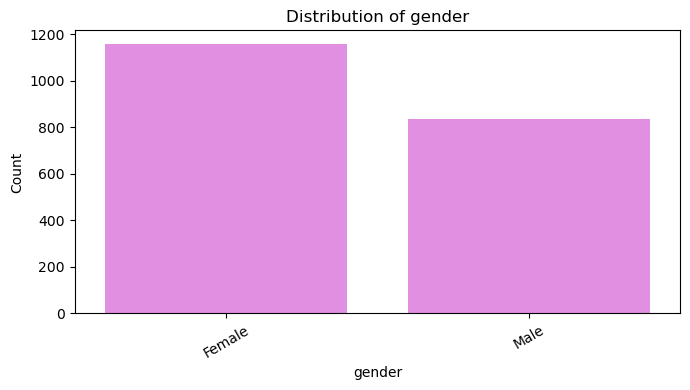

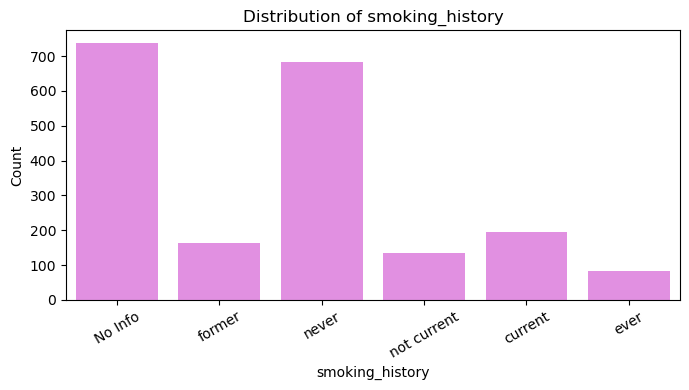

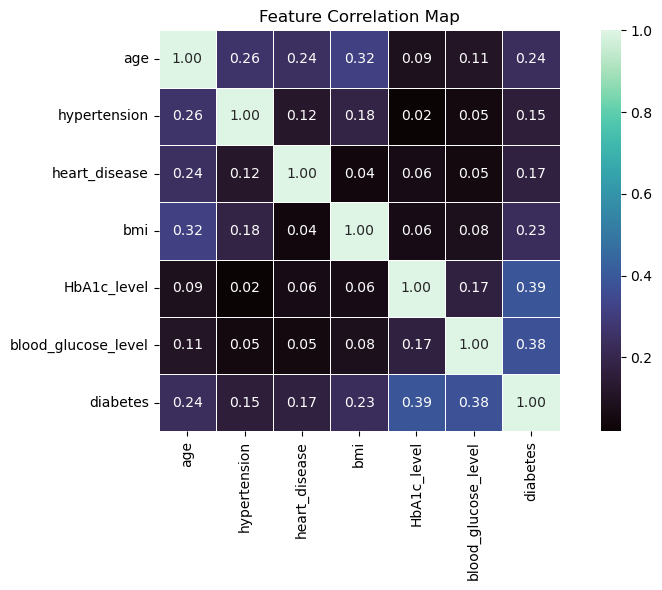

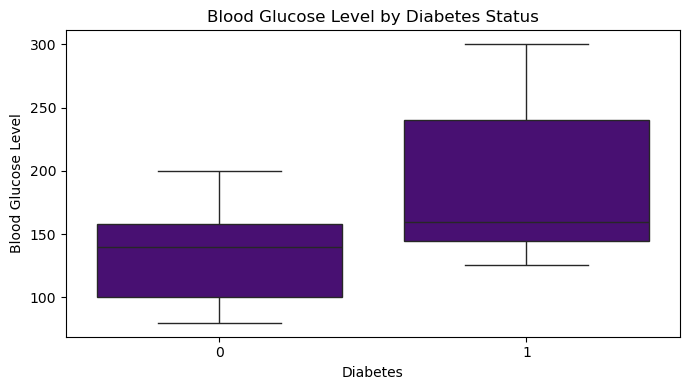

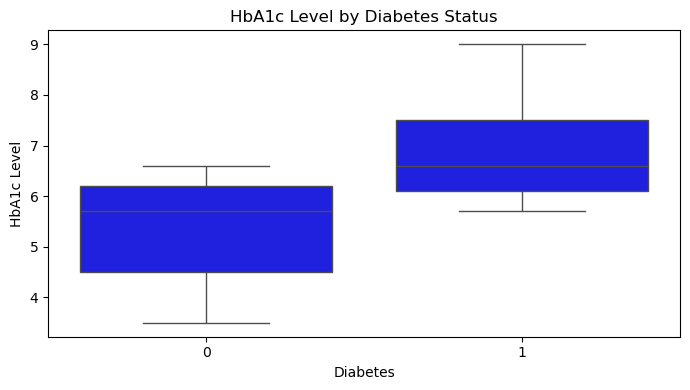

Features shape: (1996, 8)
Target shape: (1996,)
Training data: (1596, 8)
Testing data: (400, 8)
Logistic Regression model trained successfully.
First 10 predictions:
[0 0 1 0 0 0 0 0 1 0]
Logistic Regression Results
---------------------------
Accuracy    : 0.945
Precision   : 0.7241379310344828
Recall      : 0.6
Weighted F1 : 0.9426460597826087
ROC-AUC     : 0.952720156555773
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       365
           1       0.72      0.60      0.66        35

    accuracy                           0.94       400
   macro avg       0.84      0.79      0.81       400
weighted avg       0.94      0.94      0.94       400



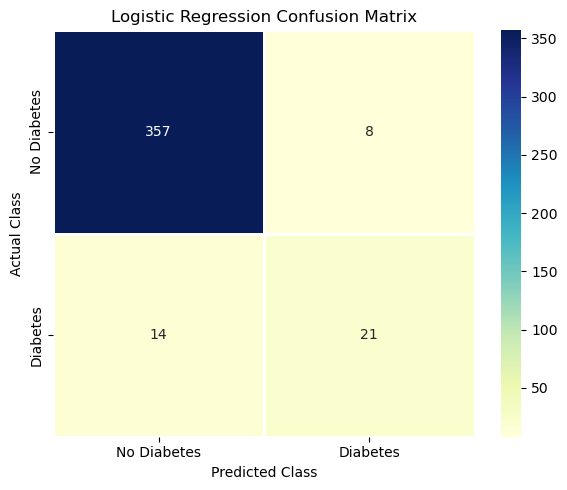

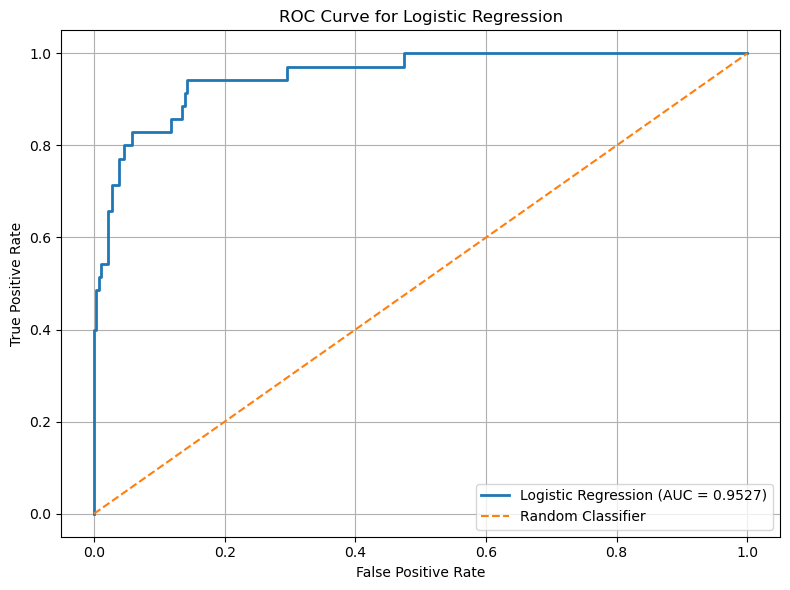

In [47]:
%run "classification1_LR.ipynb"

In [50]:
print("Model comparison")
comparison = pd.DataFrame({
    "Metrics": ["Accuracy","Precision","Recall","Weighted F1","ROC-AUC"],
    "Logistic Regression": [lr_accuracy,lr_precision,lr_recall,lr_f1,lr_auc],
    "KNN": [knn_accuracy,knn_precision,knn_recall,knn_f1,knn_auc]})

comparison

Model comparison


,Metrics,Logistic Regression,KNN
0,Accuracy,0.945000,0.955000
1,Precision,0.724138,0.857143
2,Recall,0.600000,0.545455
3,Weighted F1,0.942646,0.950362
4,ROC-AUC,0.952720,0.892783


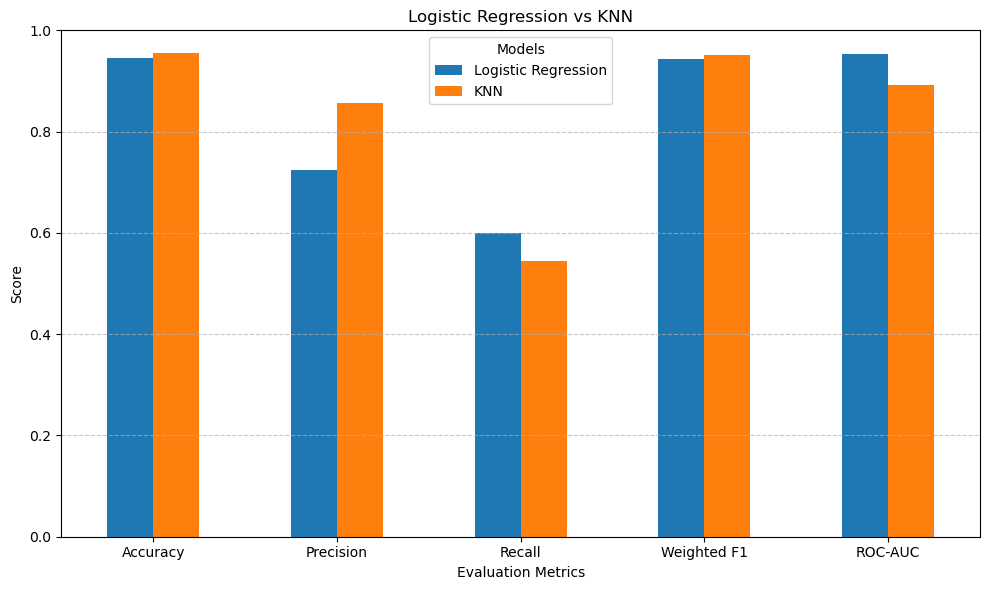

In [51]:
comparison.set_index("Metrics").plot(kind="bar",figsize=(10, 6))

plt.title("Logistic Regression vs KNN")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Models")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()